In [8]:
# =============================================================================
# SEIR MODEL PARAMETER ESTIMATION FOR THE 2014-2016 LIBERIA EBOLA OUTBREAK
# =============================================================================
#
# PARAMETER STRATEGY:
#   This script fits an SEIR compartmental model to cumulative Ebola case data
#   from Liberia. Because our data consists only of daily cumulative case counts,
#   we can realistically estimate just one parameter directly from the data:
#
#     - beta (β): the transmission/contact rate  --> FIT FROM DATA (visually)
#
#   The remaining epidemiological parameters are fixed from published literature:
#
#     - sigma (σ): incubation rate = 1/5.61 days  --> FROM LITERATURE
#     - gamma (γ): recovery rate  = 1/5.3  days   --> FROM LITERATURE
#
# ESTIMATION STRATEGY FOR BETA:
#   In the SEIR model, the cumulative number of cases at time t is represented
#   by N - S(t): the total population minus those still susceptible, capturing
#   everyone who has ever left the susceptible compartment (exposed, infected,
#   or recovered). We therefore overlay the model's N - S(t) curve against the
#   observed cumulative case counts and tune beta visually, searching for the
#   value that best aligns the model trajectory with the real data.
#
#   --> Optimal beta found: β = 0.164
#
# OUTPUTS:
#   1. SEIR compartment dynamics plot: S(t), E(t), I(t), R(t) over 572 days
#   2. Model vs. observed cumulative cases overlay used to tune beta
# =============================================================================

In [9]:
# imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

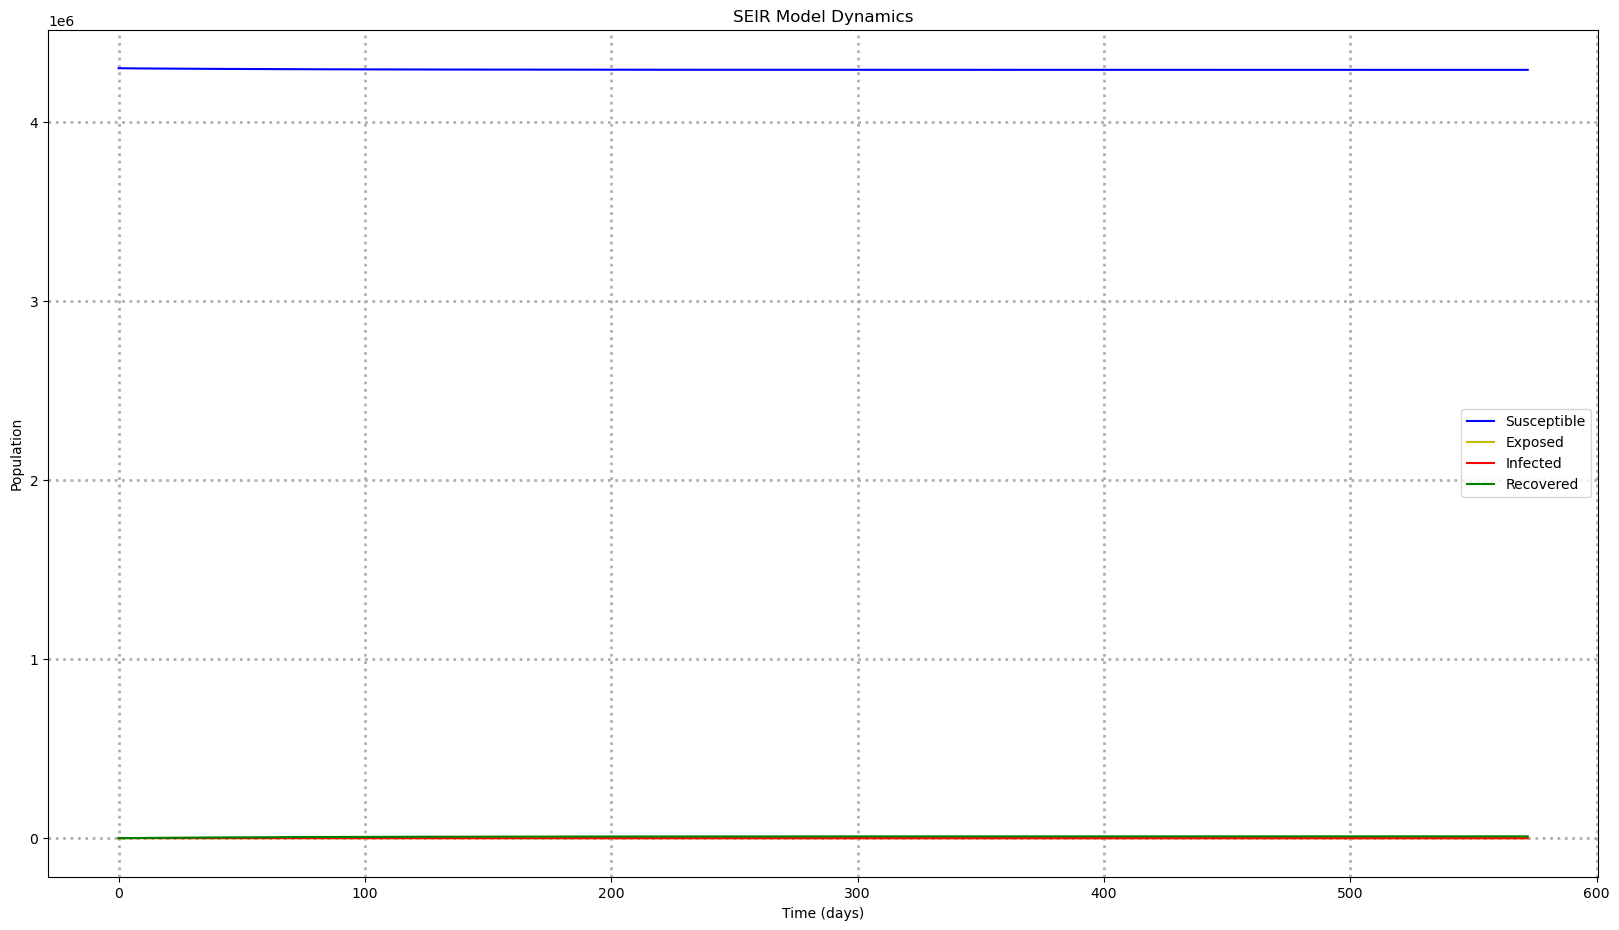

In [10]:
# SETTING UP THE MODEL

# theotal population we are modeling -  N
N = 4.3e6
# the initial number of infected and recovered individuals in our data
I0, R0 = 1378, 0
# the initial number of exposed individuals in our data
E0 = 0
# everyone else, S0, is susceptible to infection initially
S0 = N - I0 - R0 - E0
# the contact rate, beta, incubation rate, sigma, and mean recovery rate, gamma
beta, sigma, gamma = 0.164, 1/5.61, 1/5.3
# the time points (days) over which we want to predict using our model
t = np.linspace(0, 572, 572)

# the SEIR model differential equations
def deriv(t, y, N, beta, sigma, gamma):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

# here we set the initial conditions vector
y0 = S0, E0, I0, R0
# and use scipy to solve the system of differential equations
sol = solve_ivp(deriv, [0, 572], y0, args=(N, beta, sigma, gamma), t_eval=t)

# extract the results
S, E, I, R = sol.y

# plot the data on four separate curves for S(t), E(t), I(t) and R(t)
plt.figure(figsize=(20,11))
plt.plot(t, S, 'b', label='Susceptible')
plt.plot(t, E, 'y', label='Exposed')
plt.plot(t, I, 'r', label='Infected')
plt.plot(t, R, 'g', label='Recovered')
plt.title("SEIR Model Dynamics")
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.legend()
plt.grid(lw=2,ls=":")
plt.show()

In [11]:
# imports 
from data_loader import load_and_clean_ebola_data

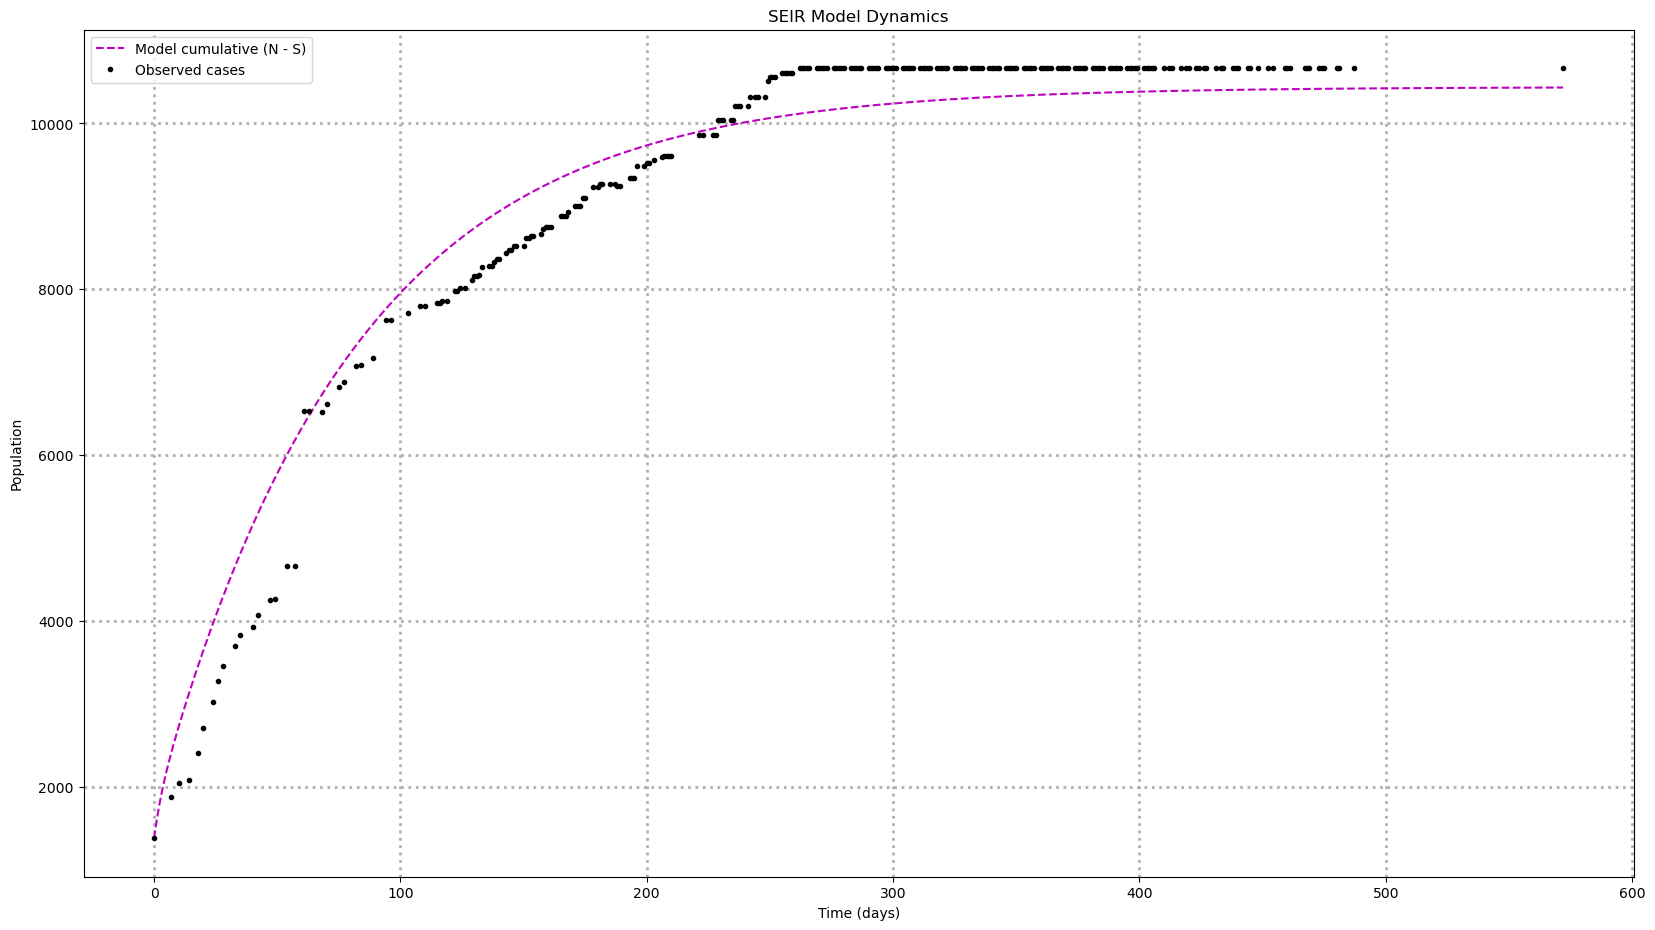

In [12]:
# VISUALLY COMPARING THE MODEL TO THE DATA TO TUNE THE CONTACT RATE BETA

# import and clean data
df_liberia = load_and_clean_ebola_data("ebola_2014_2016_clean.csv", country="Liberia", date_col="Date", cases_col="Cumulative no. of confirmed, probable and suspected cases")

# plot the cumulative number of cases from the model (N - S) against the observed cumulative cases from the data
plt.figure(figsize=(20,11))
plt.plot(t, N - S, 'm--', label='Model cumulative (N - S)')
plt.plot(df_liberia["t"], df_liberia["Cumulative no. of confirmed, probable and suspected cases"], 'ko', markersize=3, label='Observed cases')
plt.title("SEIR Model Dynamics")
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.legend()
plt.grid(lw=2,ls=":")
plt.show()